In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

In [3]:
N = 10 # oscillator Hilbert space dimension
w_q = 2.0 * np.pi * 3.0 # Qubit freq (GHz)
Ej = 2.0 * np.pi * 8 # qubit Ej (GHz)

# get EC from w_q and Ej
Ec = ((-2*w_q + 8*Ej) - np.sqrt((-2*w_q + 8*Ej)**2 - 4*w_q**2)) / 2 # in rad / s (GHz)
# the negative branch gives correct Ec

# --------------------------
# Operators
# --------------------------
a = qt.destroy(N)
n = a.dag() * a
I = qt.qeye(N)

# --------------------------
# Functions
# --------------------------
def linear_ramp(t, t_r, direction):
    # ramps linearly from 0 to 1
    # if direction == "up": the ramp goes 0 -> 1 from 0 to t_r
    # if direction == "down": the ramp goes 1 -> 0 from 0 to t_r
    if direction == "up":
        if t < 0.0:
            return 0.0
        elif t < t_r:
            return t / t_r
        else:
            return 1.0
    elif direction == "down":
        if t < 0.0:
            return 1.0
        elif t < t_r:
            return 1.0 - t / t_r
        else:
            return 0.0
    else:
        raise ValueError("direction must be 'up' or 'down'")

def drive_function(t, args):
    """
    args["t_r"] is ramp time
    args["t_p"] is plateau time
    """
    if t < 0.0:
        return 0.0
    if t < args["t_r"]:
        return linear_ramp(t, args["t_r"], direction="up") * np.cos(args["w_d"] * t) * args["epsilon"]
    if t < args["t_r"] + args["t_p"]:
        return 1.0 * np.cos(args["w_d"] * t) * args["epsilon"]
    if t < 2 * args["t_r"] + args["t_p"]:
        return linear_ramp(t - args["t_r"] - args["t_p"], args["t_r"], direction="down") * np.cos(args["w_d"] * t) * args["epsilon"]
    return 0.0

def cosine_nl(x):
    return x.cosm() - I + x**2 / 2

def make_time_array(t_r, t_p, dt):
    t_end = t_p + 2 * t_r
    return np.arange(0, t_end + 0.5*dt, dt)

# proper hamiltonain, w_q includes anharmonicity but the first term of H0 does not
H0 = np.sqrt(8 * Ej * Ec) * n - Ej * cosine_nl((2 * Ec / Ej)**(1/4) * (a + a.dag()))
evals, evecs = H0.eigenstates()

def run(psi_0, times, e_ops, t_r, t_p, w_d, epsilon):
    args = {"t_r": t_r, "t_p": t_p, "w_d": w_d, "epsilon": epsilon}
    H = [
        H0,
        [a + a.dag(), drive_function],
    ]
    res = qt.sesolve(H, psi_0, times, e_ops=e_ops, args=args, options={"store_states": True})

    return res.states, res.expect

def projector_onto_states(states):
    # states: list of Qobj state vectors
    P = 0 * (states[0] * states[0].dag())   # zero operator with correct type/dims
    for psi in states:
        P += psi * psi.dag()
    return P

In [59]:
print(Ec / (2 * np.pi))
print(Ej / (2 * np.pi))
print((np.sqrt(8 * Ej * Ec) - Ec) / (2 * np.pi))
print(Ej / Ec)

0.1555897962880848
8.0
2.999999999999992
51.41725351441087


# Rabi

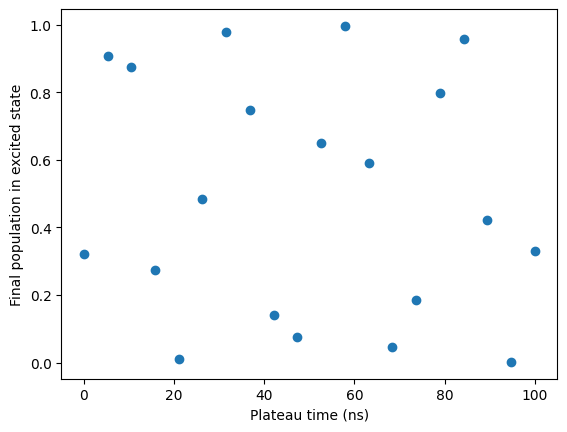

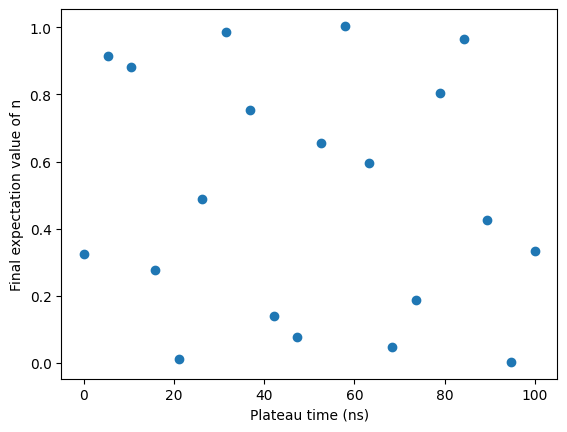

In [46]:
t_p_array = np.linspace(0, 100, 20)
t_r = 50
epsilon = 1
w_d = evals[1] - evals[0] # the actual energy difference, drive on resonance 

final_expect_excited = []
final_expect_num = []
for i, t_p in enumerate(t_p_array):
    times = make_time_array(t_r, t_p, dt=1)
    psi_0 = evecs[0]  # ground state
    e_ops = [projector_onto_states([evecs[1]]), n]
    states, expect = run(psi_0, times, e_ops, t_r, t_p, w_d, epsilon)

    final_expect_excited.append(np.real(expect[0][-1]))
    final_expect_num.append(np.real(expect[1][-1]))

plt.scatter(t_p_array, final_expect_excited)
plt.xlabel("Plateau time (ns)")
plt.ylabel("Final population in excited state")
plt.show()

plt.scatter(t_p_array, final_expect_num)
plt.xlabel("Plateau time (ns)")
plt.ylabel("Final expectation value of n")
plt.show()

2.991854439325278


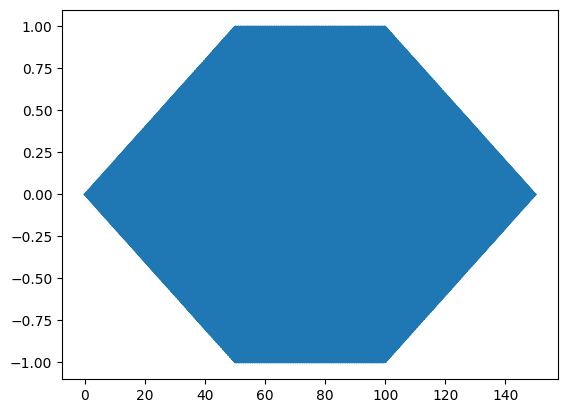

In [60]:
print((evals[1] - evals[0]) / (2 * np.pi))

times = make_time_array(t_r, t_p, dt=0.01)
args = {"t_r" : t_r, "t_p": t_p, "w_d": w_d, "epsilon": epsilon}
drive_array = []
for i, time in enumerate(times):
    drive_array.append(drive_function(time, args))
plt.plot(times, drive_array)
plt.show()

# 2D spectroscopy

In [4]:
t_p = 50
t_r = 50
epsilon_array = np.linspace(0, 3, 30)
w_d_resonance = evals[1] - evals[0]
delta_omega = 0.2
w_d_array = np.linspace(w_d_resonance - delta_omega, w_d_resonance + delta_omega, 10)

times = make_time_array(t_r, t_p, dt=1)
psi_0 = evecs[0]  # ground state
e_ops = [projector_onto_states([evecs[1]])]

final_expect_excited = np.zeros((len(w_d_array), len(epsilon_array)))
final_expect_num = np.zeros((len(w_d_array), len(epsilon_array)))
for i, epsilon in enumerate(epsilon_array):
    for j, w_d in enumerate(w_d_array):
        states, expect = run(psi_0, times, e_ops, t_r, t_p, w_d, epsilon)
        final_expect_excited[j][i] = np.real(expect[0][-1])
        if j == 1:
            print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


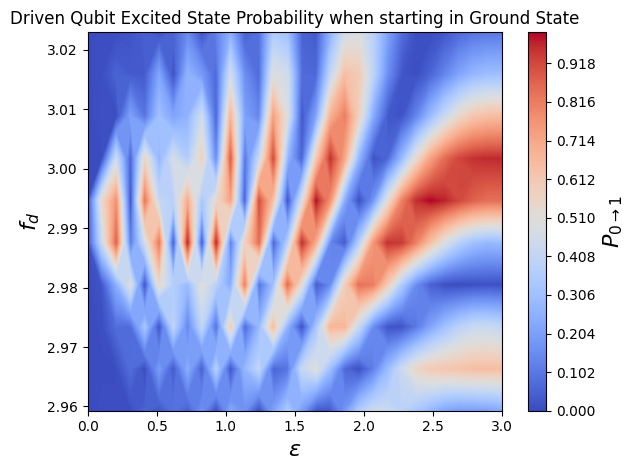

In [6]:
plt.figure()
plt.contourf(epsilon_array, w_d_array / (2 * np.pi), final_expect_excited, levels=500, cmap='coolwarm')

cbar = plt.colorbar()
cbar.set_label(r'$P_{0 \to 1}$', fontsize=16)

plt.xlabel(r'$\epsilon$', fontsize=16)
plt.ylabel(r'$f_d$', fontsize=16)
plt.title('Driven Qubit Excited State Probability when starting in Ground State')
plt.tight_layout()
plt.show()